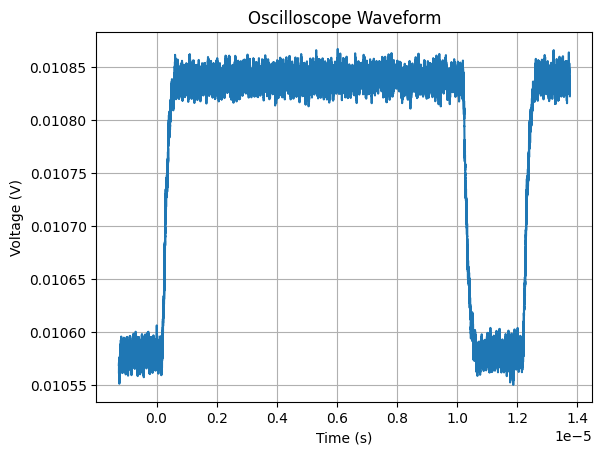

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Load CSV (skip header row)
data = np.loadtxt("tau_2uS/averaged_waveform.csv", delimiter=",", skiprows=1)

time = data[:, 0]
voltage = data[:, 1]

# Plot
plt.figure()
plt.plot(time, voltage)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Oscilloscope Waveform")
plt.grid(True)
plt.show()


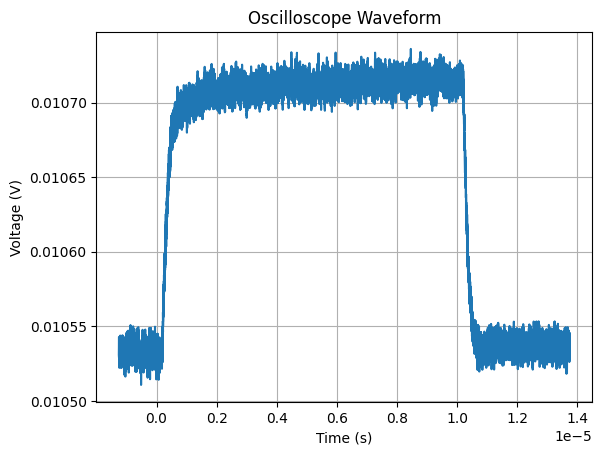

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Load CSV (skip header row)
data = np.loadtxt("tau_1264uS_27/averaged_waveform.csv", delimiter=",", skiprows=1)

time = data[:, 0]
voltage = data[:, 1]

# Plot
plt.figure()
plt.plot(time, voltage)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Oscilloscope Waveform")
plt.grid(True)
plt.show()


---

In [21]:
import pandas as pd
import glob

num_tau = "tau_1264uS_27"
files = sorted(glob.glob(f"{num_tau}/waveform_*.csv"))

dataframes = []

for f in files:
    df_read = pd.read_csv(f)
    dataframes.append(df_read["Voltage (V)"])

# combine voltages column-wise
combined = pd.concat(dataframes, axis=1)

# compute average voltage
avg_voltage = combined.mean(axis=1)

# use time from first file
time_read = pd.read_csv(files[0])["Time (s)"]

avg_df = pd.DataFrame({
    "Time (s)": time_read,
    "Voltage (V)": avg_voltage 
    # Please add STD.DEV
})


avg_df.to_csv(f"{num_tau}/averaged_waveform.csv", index=False)


In [ ]:
import pandas as pd
import glob

num_tau = 2

files = glob.glob(f"tau_{num_tau}uS/waveform_*.csv")

dataframes = []

for i, f in enumerate(files):
    # if i 
    df_read = pd.read_csv(f)
    dataframes.append(df_read["Voltage (V)"])

# combine voltages column-wise
combined = pd.concat(dataframes, axis=1)

# compute average voltage
avg_voltage = combined.mean(axis=1)

# use time from first file
time_read = pd.read_csv(files[0])["Time (s)"]

avg_df = pd.DataFrame({
    "Time (s)": time_read,
    "Voltage (V)": avg_voltage 
    # Please add STD.DEV
})


avg_df.to_csv(f"tau_{num_tau}uS/averaged_waveform.csv", index=False)

In [7]:
import os

def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

# Example usage:
directory_to_scan = '.' # Scans the current working directory
folders = list_folder_names_os(directory_to_scan)

# def list_files_os(directory_path):
#     files_list = []
#     # Iterate over all entries in the directory
#     for entry_name in os.listdir(directory_path):
#         # Create the full path for each entry
#         full_path = os.path.join(directory_path, entry_name)
#         # Check if the entry is a file
#         if os.path.isfile(full_path):
#             files_list.append(entry_name)
#     return files_list

def num_files(directory_path):
    length = 0
    for entry_name in os.listdir(directory_path):
        full_path = os.path.join(directory_path, entry_name)
        if os.path.isfile(full_path):
            length += 1
    return length

files = num_files(folders[0])
print(files)

200


# Averaging Waveforms

## 1

In [ ]:
import pandas as pd

import os

def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

def num_files(directory_path):
    length = 0
    for entry_name in os.listdir(directory_path):
        full_path = os.path.join(directory_path, entry_name)
        if os.path.isfile(full_path):
            length += 1
    return length

directory_to_scan = '.' # Scans the current working directory
folders = list_folder_names_os(directory_to_scan)


for tau in folders:
    dataframe_pol = [] # polarize pulse waveform, even-numbered files
    dataframe_read = []

    num_waveform = num_files(tau)
    for i in range(0,num_waveform):
        if i % 2 != 0:
            file_name_read = f"{tau}/waveform_{i}.csv"
            df_read = pd.read_csv(file_name_read)
            dataframe_read.append(df_read["Voltage (V)"])
        else:
            file_name_pol = f"{tau}/waveform_{i}.csv"
            df_read = pd.read_csv(file_name_pol)
            dataframe_pol.append(df_read["Voltage (V)"])
        

    # combine voltages column-wise
    combined_pol = pd.concat(dataframe_pol, axis=1)
    combined_read = pd.concat(dataframe_read, axis=1)

    # compute average voltage
    avg_voltage_pol = combined_pol.mean(axis=1)
    avg_voltage_read = combined_read.mean(axis=1)

    # use time from first file
    time_read = pd.read_csv(f"{tau}/waveform_0.csv")["Time (s)"]

    avg_df_pol = pd.DataFrame({
        "Time (s)": time_read,
        "Voltage (V)": avg_voltage_pol
        # Please add STD.DEV
    })
    avg_df_read = pd.DataFrame({
        "Time (s)": time_read,
        "Voltage (V)": avg_voltage_read
        # Please add STD.DEV
    })
    avg_df_pol.to_csv(f"{tau}/averaged_waveform_pol.csv", index=False)
    avg_df_read.to_csv(f"{tau}/averaged_waveform_read.csv", index=False)

    print(f"saved to folder: {tau}")

saved to folder: tau_1078uS
saved to folder: tau_12293uS
saved to folder: tau_13uS
saved to folder: tau_154uS
saved to folder: tau_1754uS
saved to folder: tau_20000uS
saved to folder: tau_22uS
saved to folder: tau_250uS
saved to folder: tau_2855uS
saved to folder: tau_2uS
saved to folder: tau_35uS
saved to folder: tau_3uS
saved to folder: tau_407uS
saved to folder: tau_4644uS
saved to folder: tau_58uS
saved to folder: tau_5uS
saved to folder: tau_663uS
saved to folder: tau_7556uS
saved to folder: tau_8uS
saved to folder: tau_94uS


## 2 (with Std)

In [23]:
import pandas as pd
import numpy as np
import os

# --- FUNCTIONS ---
def list_folder_names(directory_path):
    return [
        name for name in os.listdir(directory_path)
        if os.path.isdir(os.path.join(directory_path, name))
    ]

def list_waveform_files(folder):
    return sorted(
        [f for f in os.listdir(folder) if f.startswith("waveform_")],
        key=lambda x: int(x.split("_")[1].split(".")[0])
    )


# --- MAIN ---
directory_to_scan = '.'
folders = list_folder_names(directory_to_scan)


for tau in folders:

    dataframe_pol = []
    dataframe_read = []

    files = list_waveform_files(tau)

    for i, file in enumerate(files):
        file_path = os.path.join(tau, file)
        df = pd.read_csv(file_path)

        if i % 2 != 0:
            dataframe_read.append(df["Voltage (V)"])
        else:
            dataframe_pol.append(df["Voltage (V)"])

    # --- COMBINE ---
    combined_pol = pd.concat(dataframe_pol, axis=1)
    combined_read = pd.concat(dataframe_read, axis=1)

    # --- MEAN ---
    avg_voltage_pol = combined_pol.mean(axis=1)
    avg_voltage_read = combined_read.mean(axis=1)

    # --- STD (THIS IS THE KEY ADDITION) ---
    std_voltage_pol = combined_pol.std(axis=1)
    std_voltage_read = combined_read.std(axis=1)

    # --- TIME ---
    time = pd.read_csv(os.path.join(tau, files[0]))["Time (s)"]

    # --- SAVE ---
    avg_df_pol = pd.DataFrame({
        "Time (s)": time,
        "Voltage (V)": avg_voltage_pol,
        "Std (V)": std_voltage_pol
    })

    avg_df_read = pd.DataFrame({
        "Time (s)": time,
        "Voltage (V)": avg_voltage_read,
        "Std (V)": std_voltage_read
    })

    avg_df_pol.to_csv(f"{tau}/averaged_waveform_pol.csv", index=False)
    avg_df_read.to_csv(f"{tau}/averaged_waveform_read.csv", index=False)

    print(f"saved to folder: {tau}")

saved to folder: tau_10028uS_36
saved to folder: tau_1004uS_26
saved to folder: tau_100uS_16
saved to folder: tau_10uS_6
saved to folder: tau_12622uS_37
saved to folder: tau_1264uS_27
saved to folder: tau_126uS_17
saved to folder: tau_12uS_7
saved to folder: tau_15888uS_38
saved to folder: tau_1591uS_28
saved to folder: tau_159uS_18
saved to folder: tau_15uS_8
saved to folder: tau_20000uS_39
saved to folder: tau_2003uS_29
saved to folder: tau_200uS_19
saved to folder: tau_20uS_9
saved to folder: tau_2521uS_30
saved to folder: tau_252uS_20
saved to folder: tau_25uS_10
saved to folder: tau_2uS
saved to folder: tau_2uS_0
saved to folder: tau_3173uS_31
saved to folder: tau_317uS_21
saved to folder: tau_31uS_11
saved to folder: tau_3994uS_32
saved to folder: tau_3uS_1
saved to folder: tau_400uS_22
saved to folder: tau_40uS_12
saved to folder: tau_4uS_2
saved to folder: tau_5028uS_33
saved to folder: tau_503uS_23
saved to folder: tau_50uS_13
saved to folder: tau_5uS_3
saved to folder: tau_63

# Plot Data

## 1 (default waveform plots)

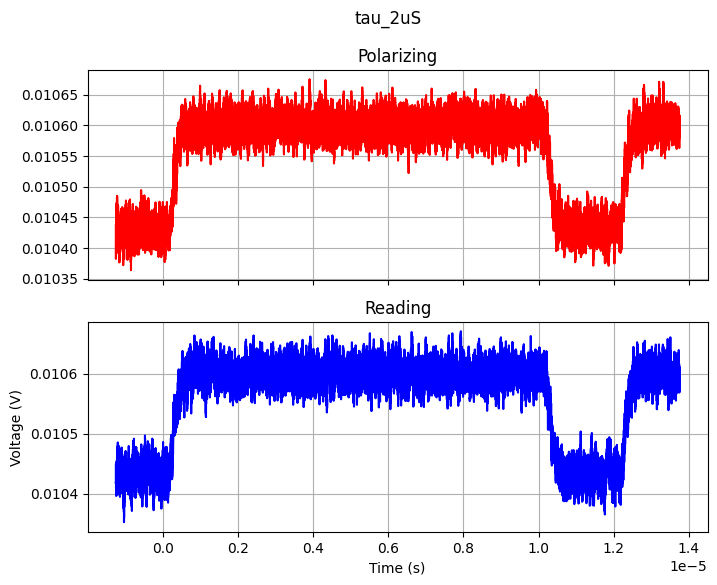

<Figure size 640x480 with 0 Axes>

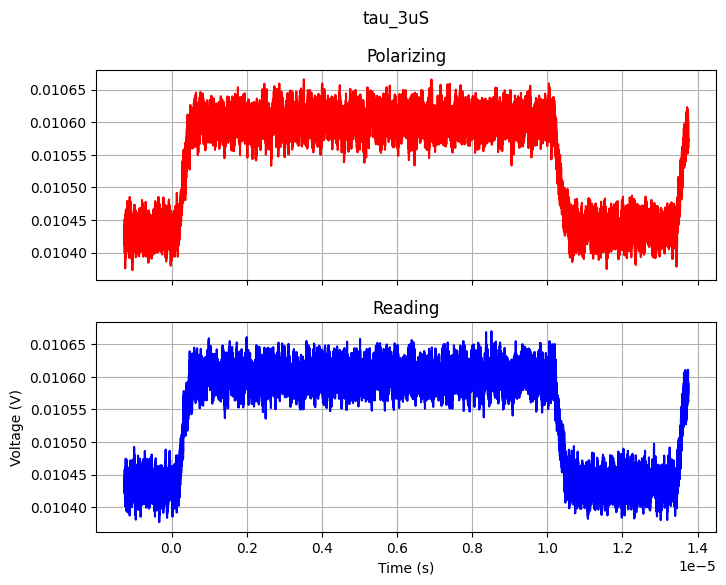

<Figure size 640x480 with 0 Axes>

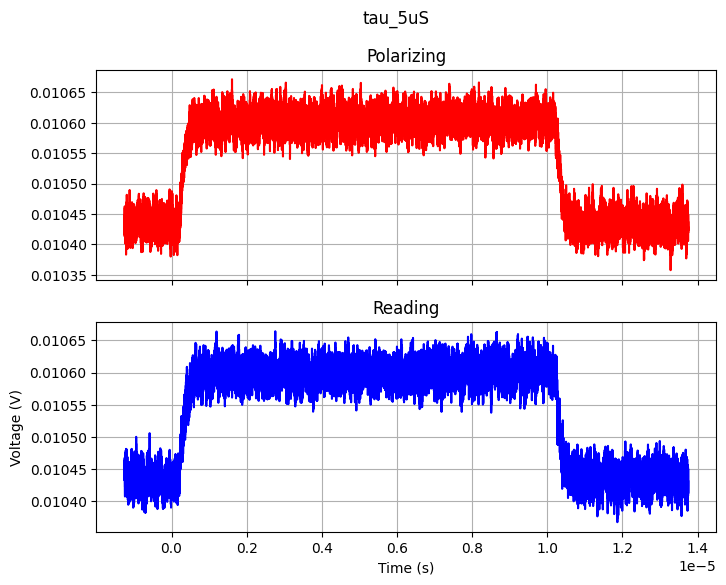

KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [5]:
import matplotlib.pyplot as plt
import os
from matplotlib.backends.backend_pdf import PdfPages

def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

directory_to_scan = '.' # Scans the current working directory
folders = list_folder_names_os(directory_to_scan)
folders = sorted(folders, key=lambda x: int(x.split('_')[1].replace('uS', '')))

file_name = input("enter file name for the plots: ")

with PdfPages(f"{file_name}.pdf") as pdf:
    for tau in folders:
        data_read = np.loadtxt(f"{tau}/averaged_waveform_read.csv", delimiter=",", skiprows=1)
        data_pol = np.loadtxt(f"{tau}/averaged_waveform_pol.csv", delimiter=",", skiprows=1)

        time_read = data_read[:, 0]
        time_pol = data_pol[:, 0]
        voltage_read = data_read[:, 1]
        voltage_pol = data_pol[:, 1]
        
        # Create a figure and a 2x2 grid of axes
        fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True) #
        fig.suptitle(tau)

        # Plot data on each subplot
        axs[0].plot(time_pol, voltage_pol, 'r-')
        axs[0].set_title('Polarizing')

        axs[1].plot(time_read, voltage_read, 'b-')
        axs[1].set_title('Reading')

        plt.xlabel("Time (s)")
        plt.ylabel("Voltage (V)")
        # plt.title("Oscilloscope Waveform")
        axs[0].grid(True)
        axs[1].grid(True)


        # Adjust layout to prevent overlapping titles and labels
        # plt.tight_layout()

        # Display all plots in a single window
        plt.show()
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)  # free memory
        
print(f"Saved to {file_name}.pdf")

## 2 (highlighted reading window)

### 2a (default)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.backends.backend_pdf import PdfPages

# --- FUNCTIONS ---
def list_folder_names(directory_path):
    return [
        name for name in os.listdir(directory_path)
        if os.path.isdir(os.path.join(directory_path, name))
    ]

def extract_tau(folder_name):
    return int(folder_name.split('_')[1].replace('uS', ''))


# --- PARAMETERS (MATCH CALCULATION!) ---
polarize_pulse_width = 10e-6
readout_window = 200e-9

read_start = 15e-9                       # reading window starts at 1 microsecond
read_end   = read_start + readout_window  # reading window ends at 1.2 microseconds
t1 = polarize_pulse_width * 0.8
t2 = t1 + readout_window


# --- GET FOLDERS ---
directory_to_scan = '.'
folders = list_folder_names(directory_to_scan)
folders = sorted(folders, key=extract_tau)


file_name = input("enter file name for the plots: ")

with PdfPages(f"{file_name}.pdf") as pdf:
    for tau in folders:

        # Load data
        data_read = pd.read_csv(f"{tau}/averaged_waveform_read.csv")
        data_pol  = pd.read_csv(f"{tau}/averaged_waveform_pol.csv")

        data_read.columns = ["Time", "Voltage"]
        data_pol.columns  = ["Time", "Voltage"]

        time_read = data_read["Time"]
        voltage_read = data_read["Voltage"]

        time_pol = data_pol["Time"]
        voltage_pol = data_pol["Voltage"]

        # --- COMPUTE SIGNAL (for display) ---
        read_mask = (time_read >= read_start) & (time_read < read_end)
        ref_mask  = (time_pol >= t1) & (time_pol < t2)

        reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
        reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])

        signal = reading_int / reference_int if reference_int != 0 else np.nan

        # --- PLOTTING ---
        fig, axs = plt.subplots(2, 1, figsize=(8, 4))
        fig.suptitle(f"{tau} | Ratio = {signal:.4e}")

        # --- POLARIZING ---
        axs[0].plot(time_pol, voltage_pol)
        axs[0].grid(True)

        # --- READING ---
        axs[1].plot(time_read, voltage_read)
        axs[1].set_xlim(read_start, read_end)   # zoom into reading window
        axs[1].grid(True)

        # --- WINDOW MARKING ---
        for ax in axs:
            # Reading window
            ax.axvspan(read_start, read_end, alpha=0.35)

            # Reference window
            ax.axvspan(t1, t2, alpha=0.2)

            # Boundary lines
            ax.axvline(read_start, linestyle='--', linewidth=1)
            ax.axvline(read_end,   linestyle='--', linewidth=1)
            ax.axvline(t1, linestyle=':', linewidth=1)
            ax.axvline(t2, linestyle=':', linewidth=1)

        # --- LABELS ---
        axs[1].set_xlabel("Time (s)")
        axs[0].set_ylabel("Voltage (V)")
        axs[1].set_ylabel("Voltage (V)")

        # Annotations
        ymax_read = max(voltage_read[read_mask]) if read_mask.any() else max(voltage_read)
        # axs[1].text(read_start + readout_window * 0.1, ymax_read * 0.9, "Read", fontsize=8)

        ymax_pol = max(voltage_pol)
        # axs[0].text(t1, ymax_pol * 0.8, "Ref", fontsize=8)

        
        # Layout
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)  # free memory
        
print(f"Saved to {file_name}.pdf")

Saved to results.pdf


### 2b (modified window)

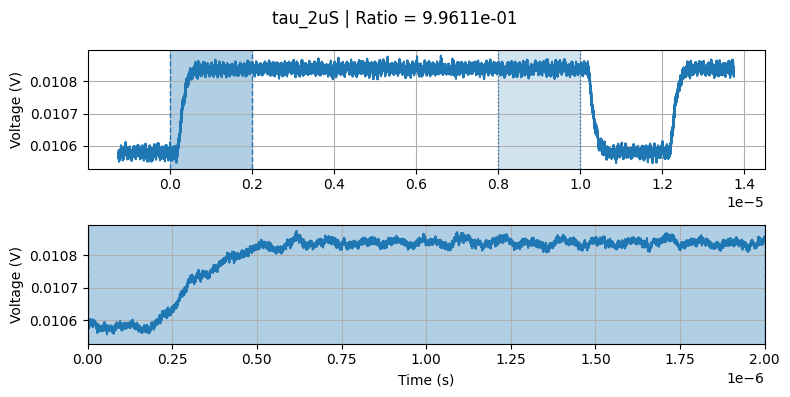

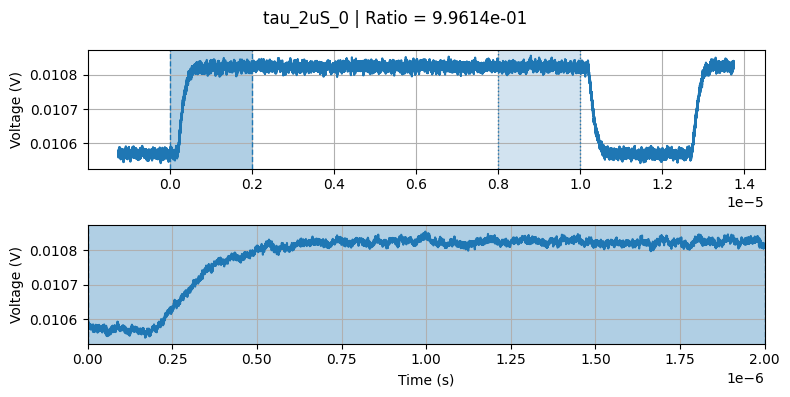

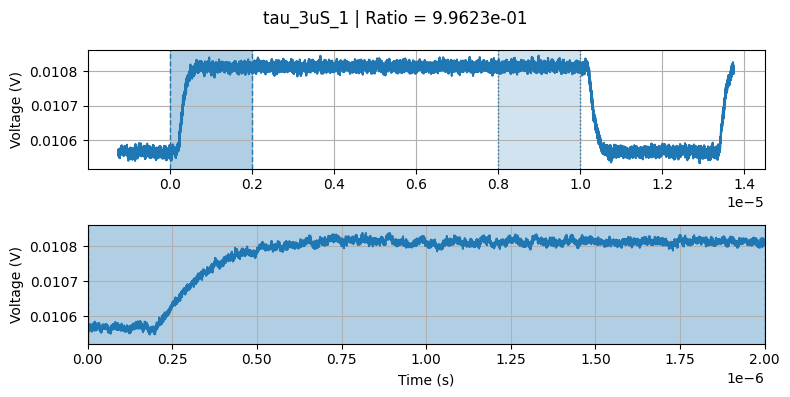

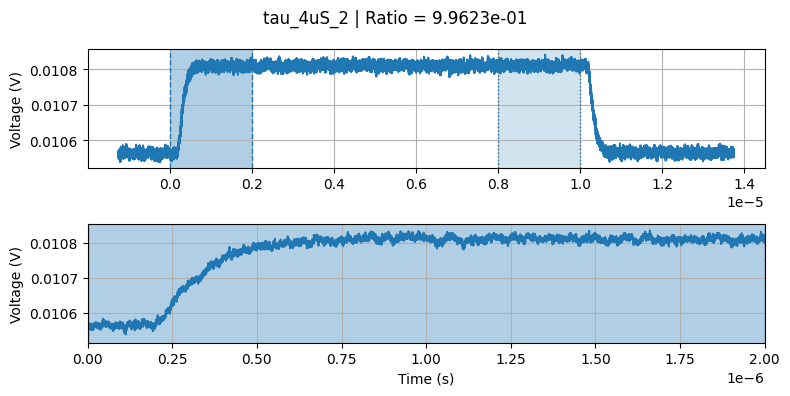

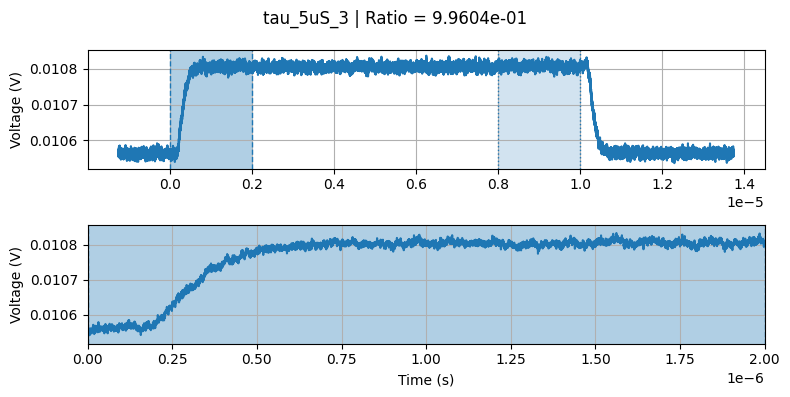

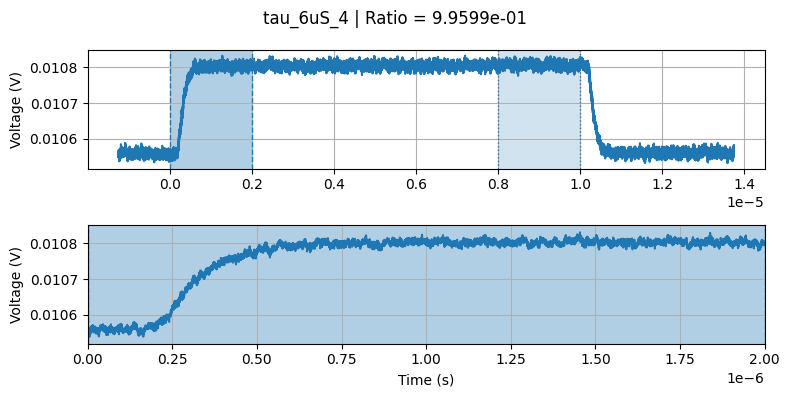

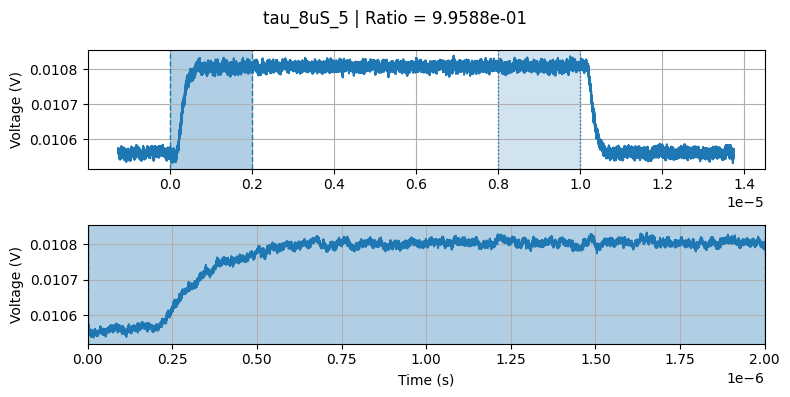

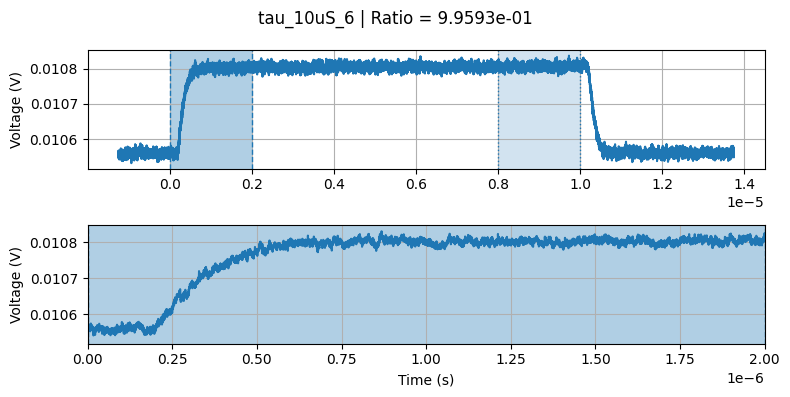

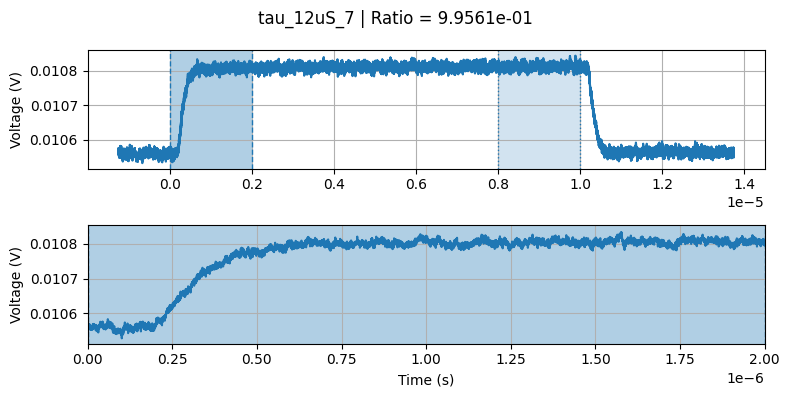

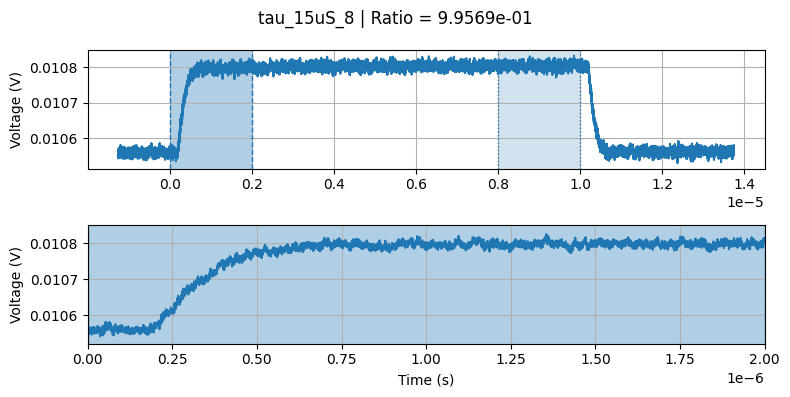

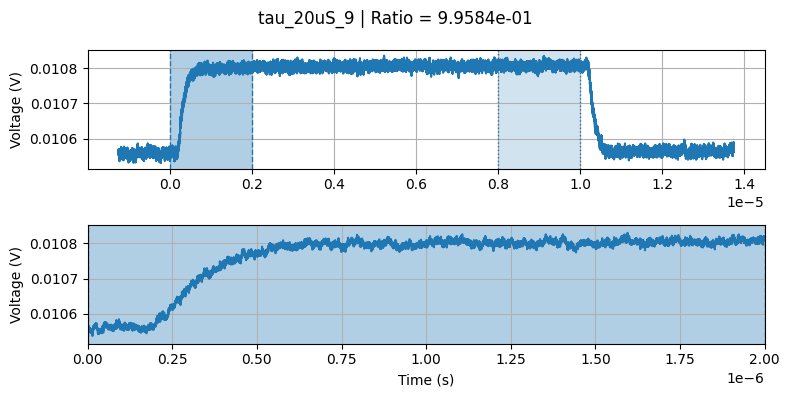

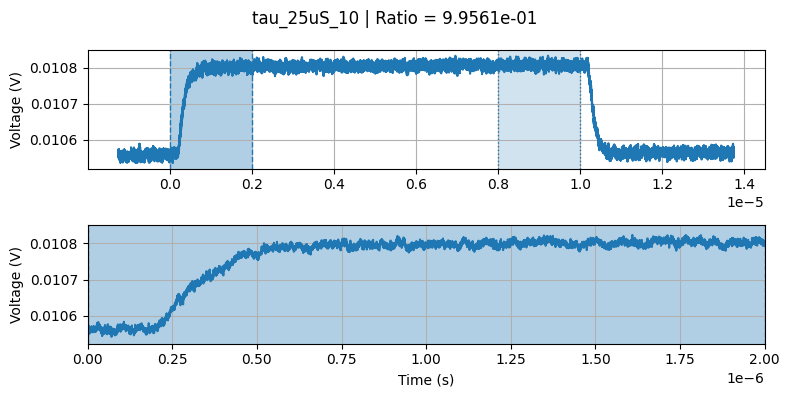

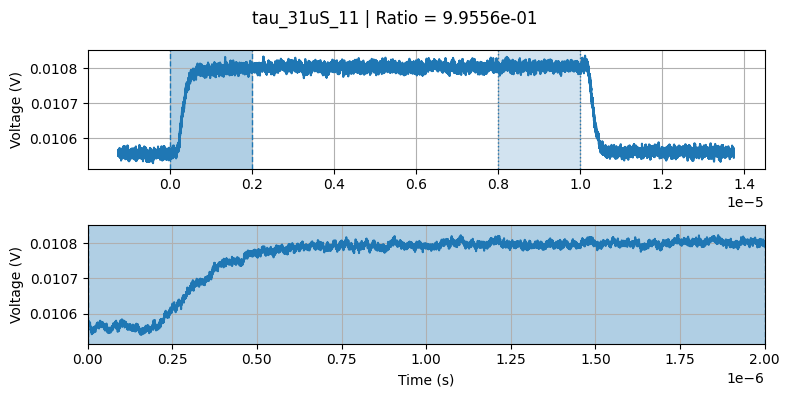

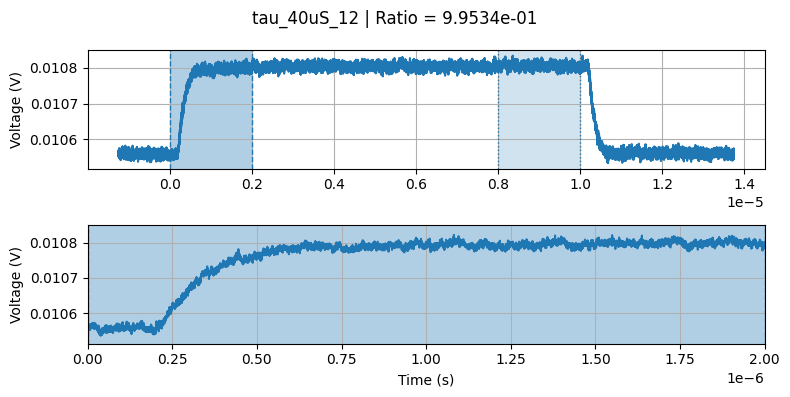

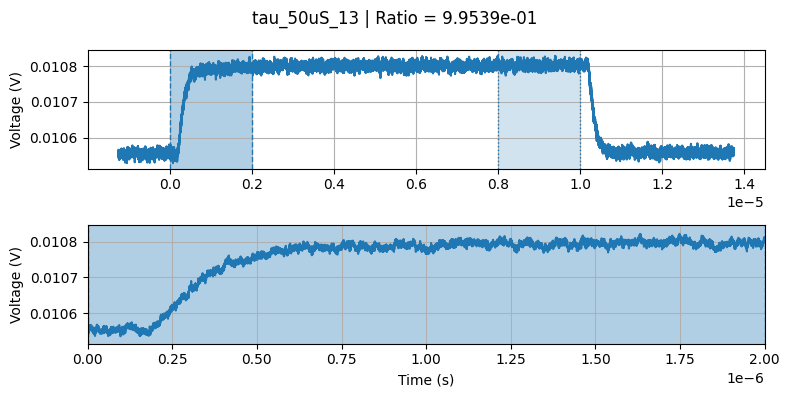

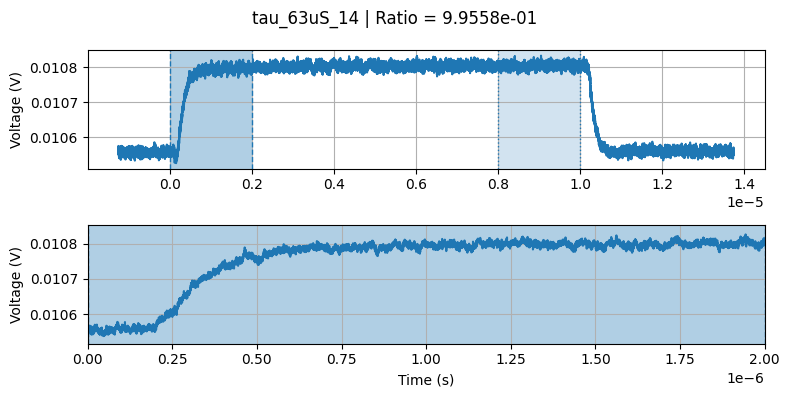

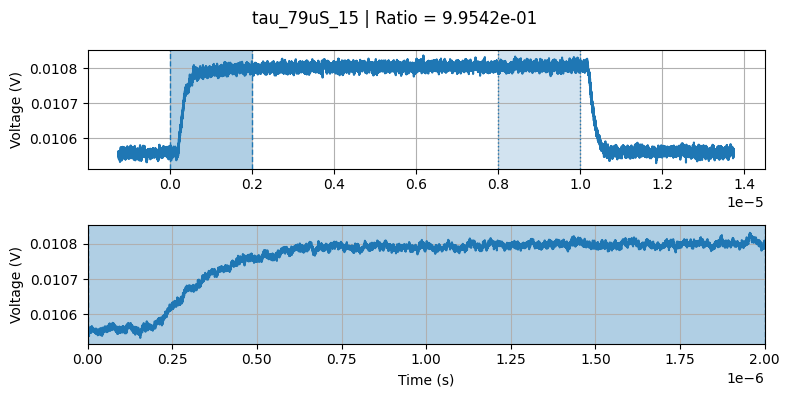

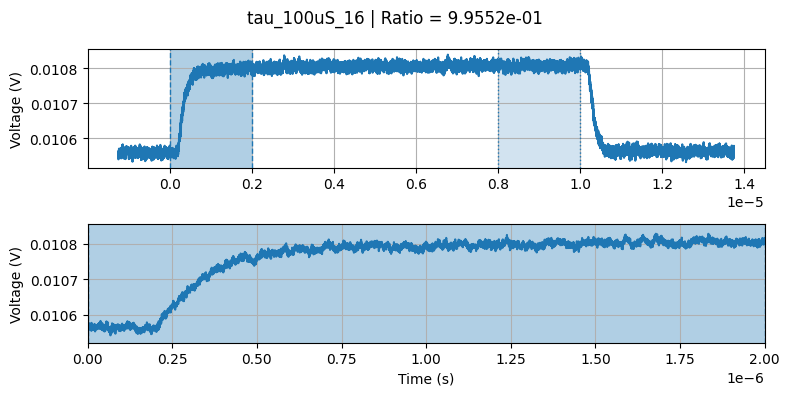

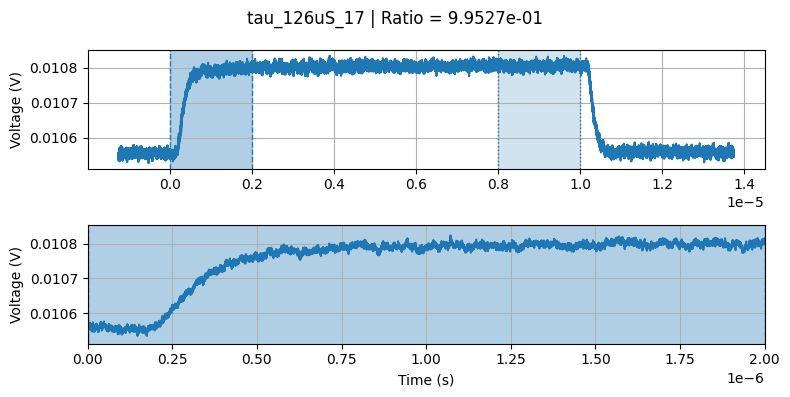

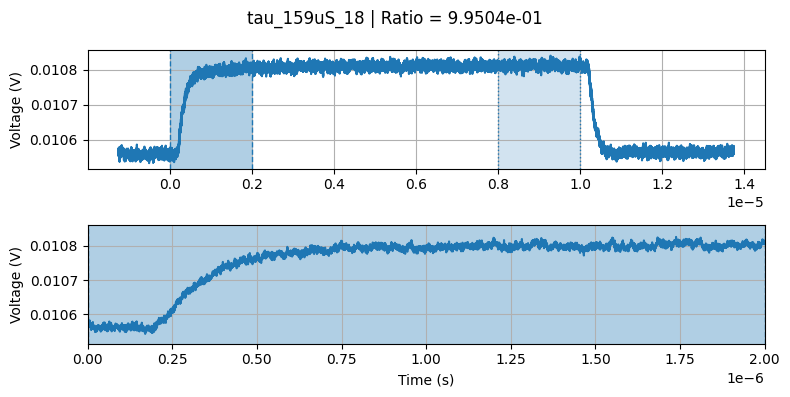

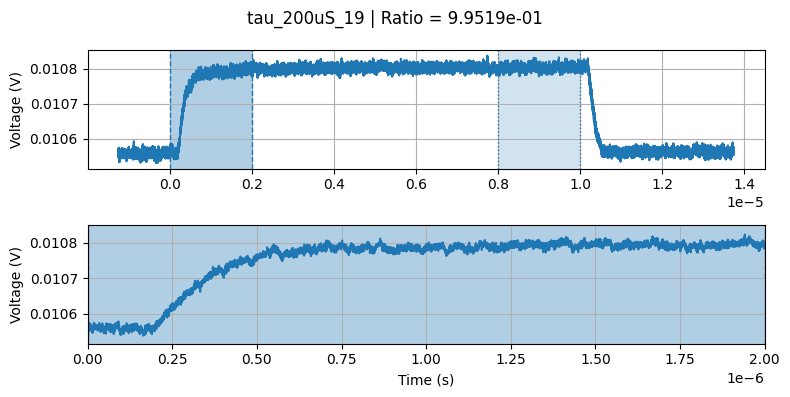

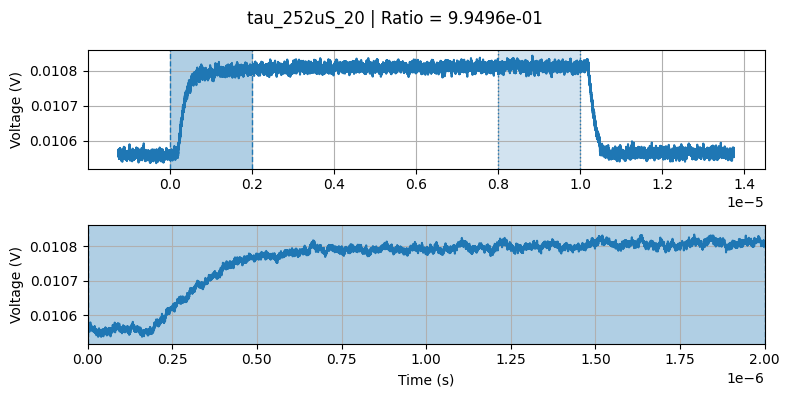

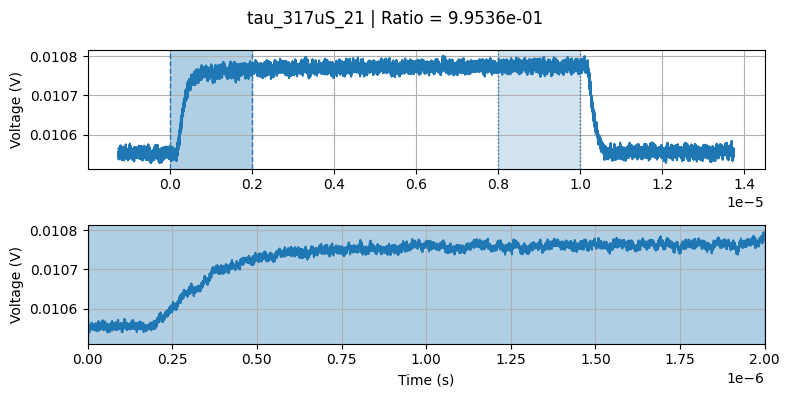

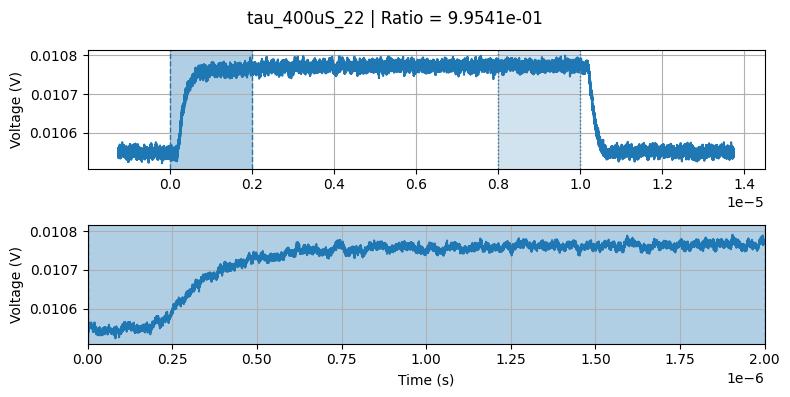

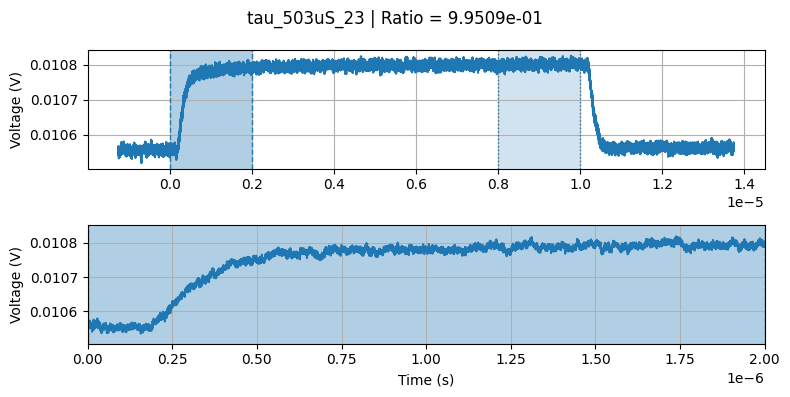

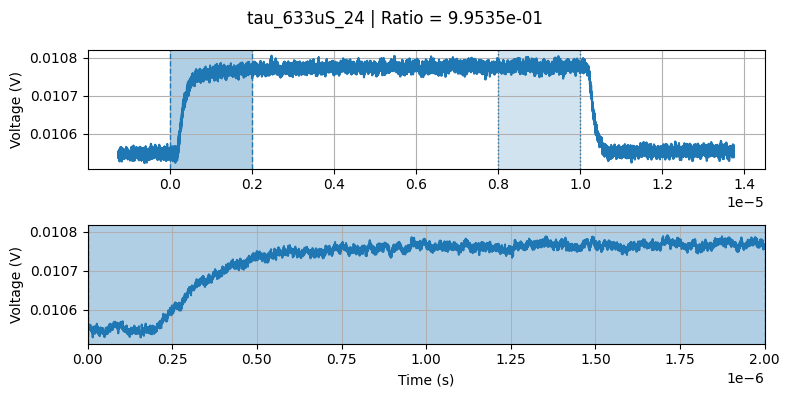

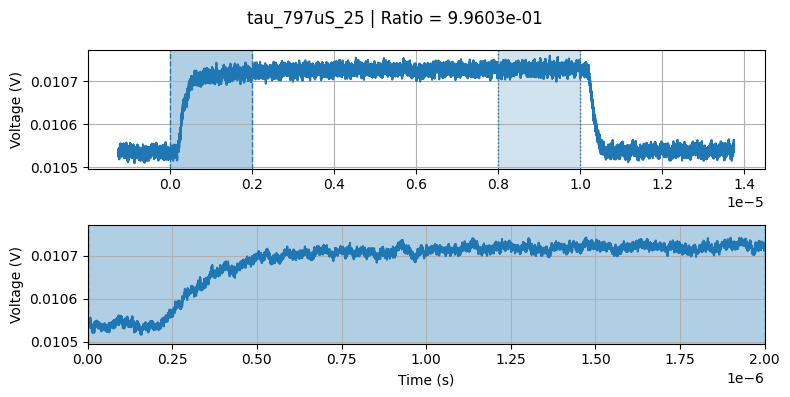

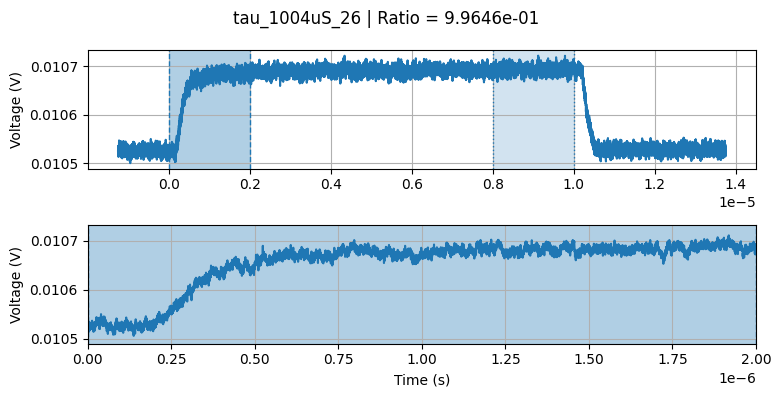

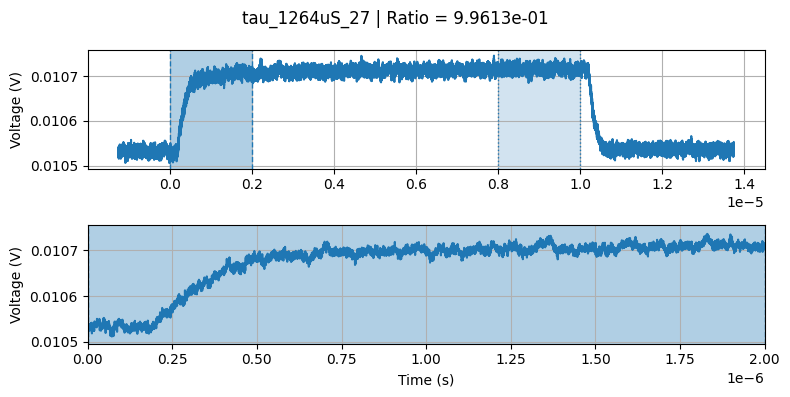

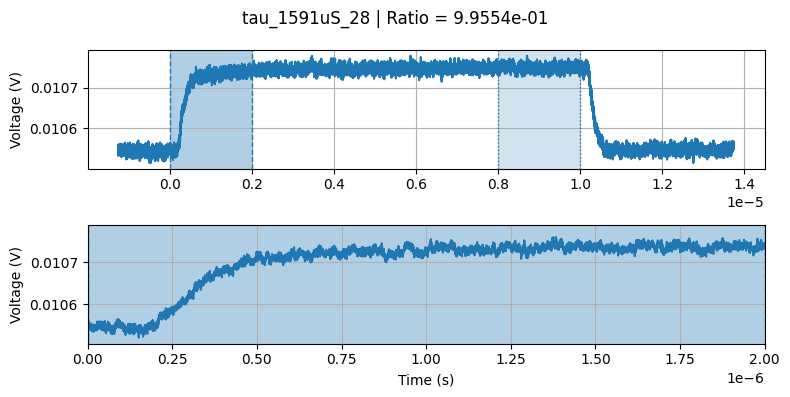

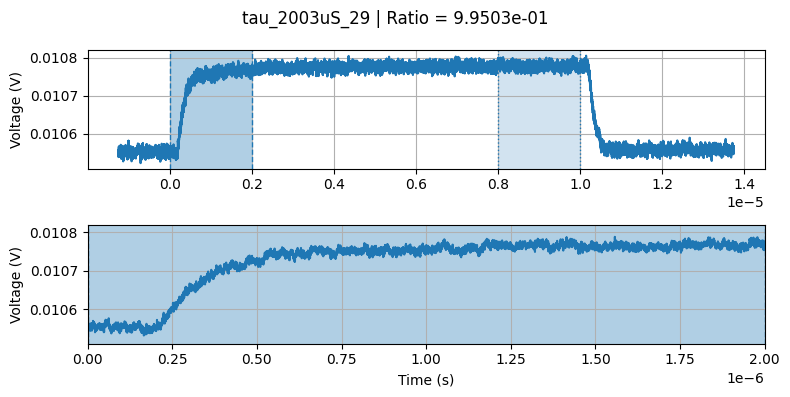

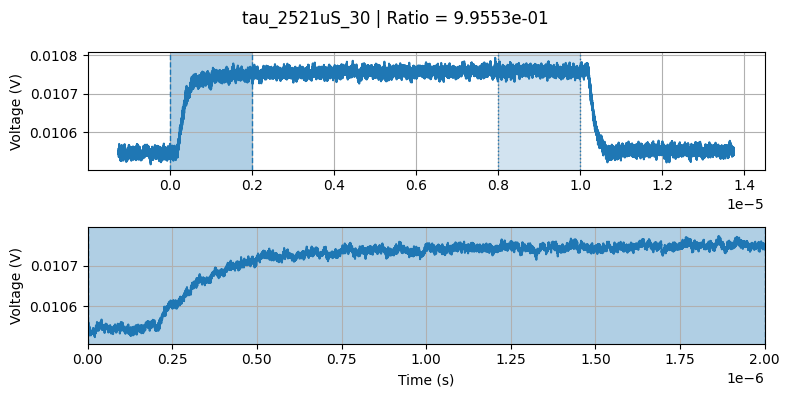

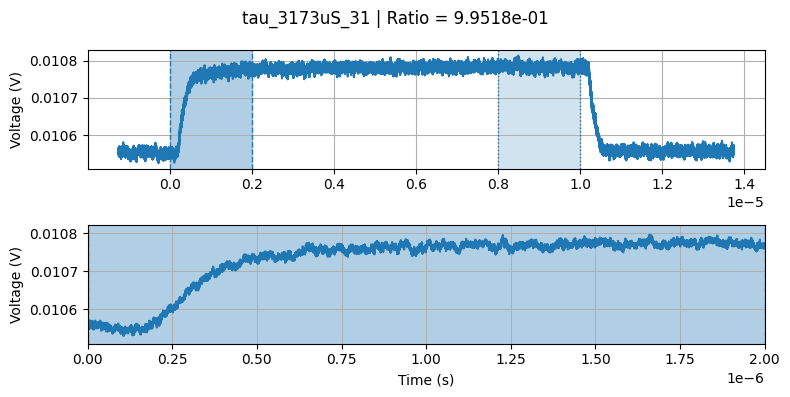

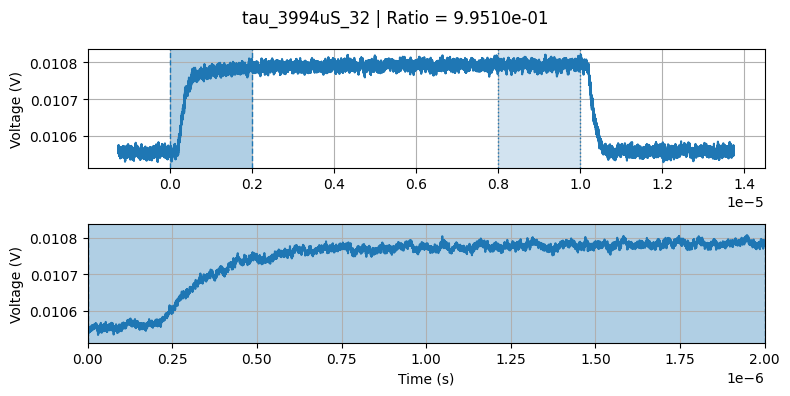

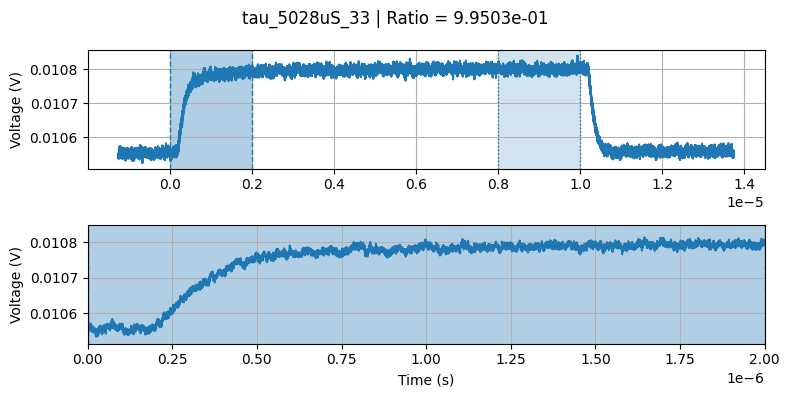

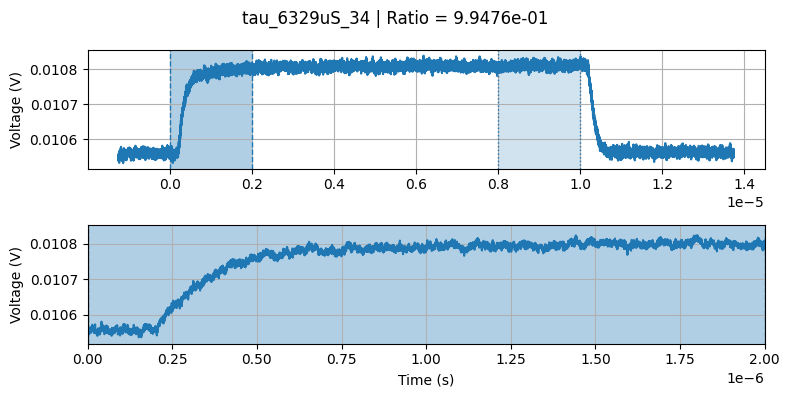

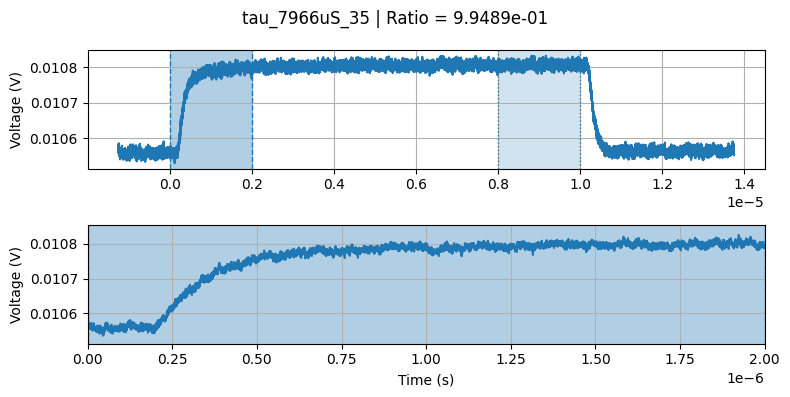

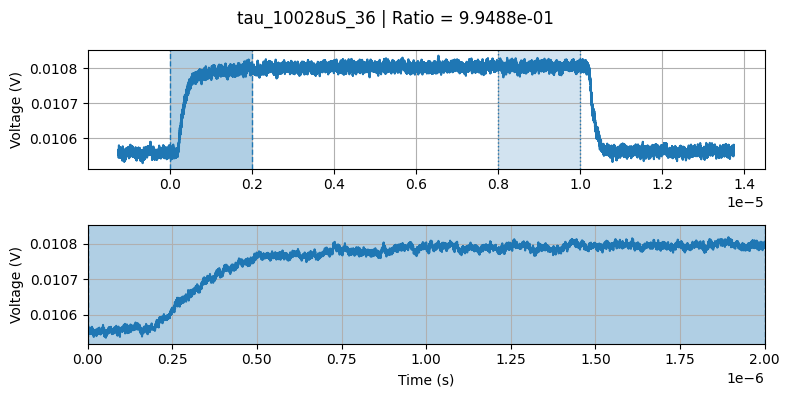

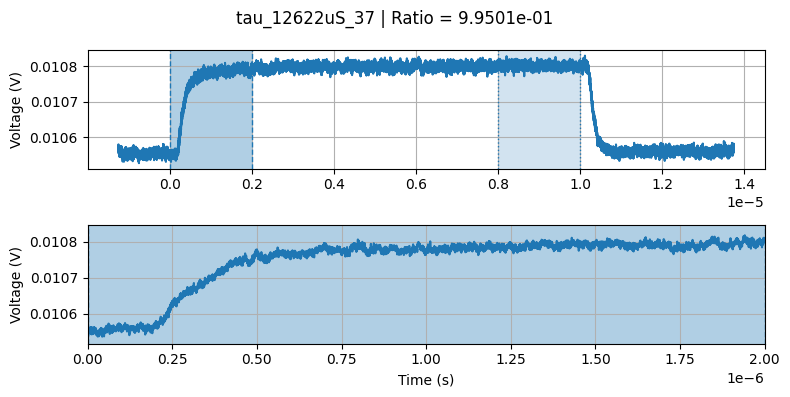

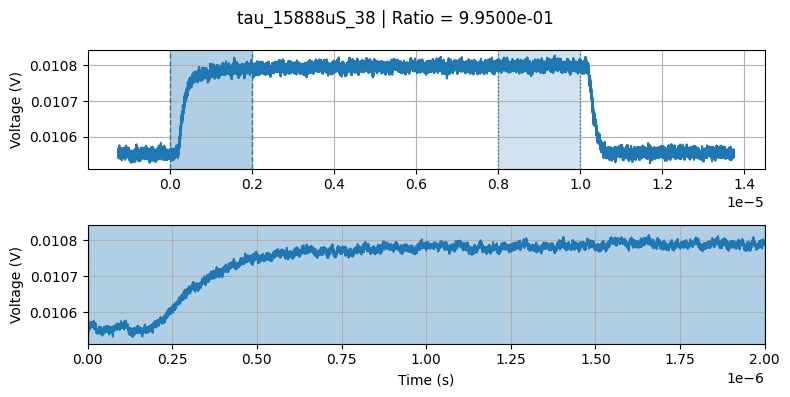

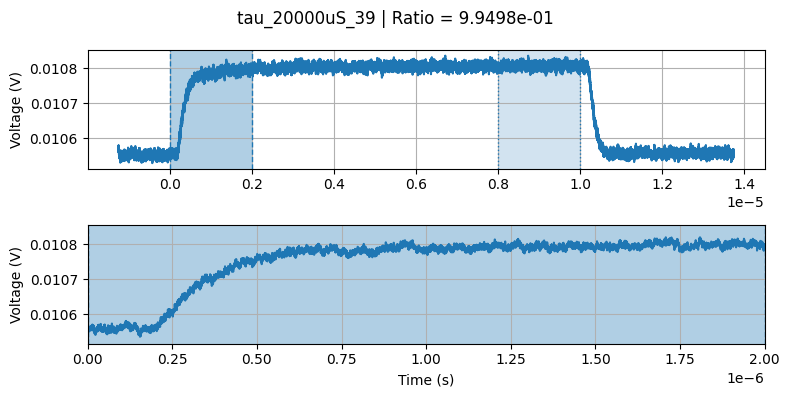

Saved to window_width2us_start0ns_0104.pdf


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.backends.backend_pdf import PdfPages

# --- FUNCTIONS ---
def list_folder_names(directory_path):
    return [
        name for name in os.listdir(directory_path)
        if os.path.isdir(os.path.join(directory_path, name))
    ]

def extract_tau(folder_name):
    return int(folder_name.split('_')[1].replace('uS', ''))


# --- PARAMETERS (MATCH CALCULATION!) ---
polarize_pulse_width = 10e-6
readout_window = 2000e-9

read_start = 0                       # reading window starts at 1 microsecond
read_end   = read_start + readout_window  # reading window ends at 1.2 microseconds
t1 = polarize_pulse_width * 0.8
t2 = t1 + readout_window


# --- GET FOLDERS ---
directory_to_scan = '.'
folders = list_folder_names(directory_to_scan)
folders = sorted(folders, key=extract_tau)


file_name = input("enter file name for the plots: ")

with PdfPages(f"{file_name}.pdf") as pdf:
    for tau in folders:

        # Load data
        data_read = pd.read_csv(f"{tau}/averaged_waveform_read.csv")
        data_pol  = pd.read_csv(f"{tau}/averaged_waveform_pol.csv")

        data_read.columns = ["Time", "Voltage","Std"]
        data_pol.columns  = ["Time", "Voltage","Std"]

        time_read = data_read["Time"]
        voltage_read = data_read["Voltage"]

        time_pol = data_pol["Time"]
        voltage_pol = data_pol["Voltage"]

        # --- COMPUTE SIGNAL (for display) ---
        read_mask = (time_read >= read_start) & (time_read < read_end)
        ref_mask  = (time_pol >= t1) & (time_pol < t2)

        reading_int = np.trapz(voltage_read[read_mask], time_read[read_mask])
        reference_int = np.trapz(voltage_pol[ref_mask], time_pol[ref_mask])

        signal = reading_int / reference_int if reference_int != 0 else np.nan

        # --- PLOTTING ---
        fig, axs = plt.subplots(2, 1, figsize=(8, 4))
        fig.suptitle(f"{tau} | Ratio = {signal:.4e}")

        # --- POLARIZING ---
        axs[0].plot(time_pol, voltage_pol)
        axs[0].grid(True)

        # --- READING ---
        axs[1].plot(time_read, voltage_read)
        axs[1].set_xlim(read_start, read_end)   # zoom into reading window
        axs[1].grid(True)

        # --- WINDOW MARKING ---
        for ax in axs:
            # Reading window
            ax.axvspan(read_start, read_end, alpha=0.35)

            # Reference window
            ax.axvspan(t1, t2, alpha=0.2)

            # Boundary lines
            ax.axvline(read_start, linestyle='--', linewidth=1)
            ax.axvline(read_end,   linestyle='--', linewidth=1)
            ax.axvline(t1, linestyle=':', linewidth=1)
            ax.axvline(t2, linestyle=':', linewidth=1)

        # --- LABELS ---
        axs[1].set_xlabel("Time (s)")
        axs[0].set_ylabel("Voltage (V)")
        axs[1].set_ylabel("Voltage (V)")

        # Annotations
        ymax_read = max(voltage_read[read_mask]) if read_mask.any() else max(voltage_read)
        # axs[1].text(read_start + readout_window * 0.1, ymax_read * 0.9, "Read", fontsize=8)

        ymax_pol = max(voltage_pol)
        # axs[0].text(t1, ymax_pol * 0.8, "Ref", fontsize=8)

        # Layout
        plt.tight_layout()
        plt.show()
        # Layout
        # plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)  # free memory
print(f"Saved to {file_name}.pdf")

# !!!

## 1

In [ ]:
import numpy as np
# FIX
def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

directory_to_scan = '.' # Scans the current working directory
tau_folders = sorted(list_folder_names_os(directory_to_scan), 
                 key=lambda x: int(x.split('_')[1].replace('uS', '')))

tau_minimum = 2
tau_maximum = 20000
n = 20
num_waveform = 200
tau = np.geomspace(tau_minimum, tau_maximum, n)

ratio_list = []

print("Dark time (us) | Ratio")

for val_t, t in enumerate(tau_folders):
    df_pol = pd.read_csv(f"{t}/averaged_waveform_pol.csv")
    df_read = pd.read_csv(f"{t}/averaged_waveform_read.csv")
    df_read.columns = ["Time","Voltage"]
    df_pol.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    
    readout_window = 200e-9

    edge = 15e-9
    t0 = readout_window
    t1 = polarize_pulse_width*0.85
    t2 = t1 + readout_window

    reading = df_read[(df_read["Time"] >= 0) & (df_read["Time"] < t0)]
    # reference = df[(df["Time"] >= t1)]
    reference = df_pol[(df_pol["Time"] >= t1) & (df_pol["Time"] <t2) ]

    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    ratio = reading_int / reference_int
    ratio_list.append(ratio)
    print(f" {tau[val_t]} | {ratio:.4f}")

print(ratio_list)

import pandas as pd

# Create DataFrame
df_result = pd.DataFrame({
    "Tau (us)": tau,
    "Ratio": ratio_list
})

file_name = input("enter file name for the results: ")
# Save to Excel
df_result.to_excel(f"{file_name}_1.xlsx", index=False)

print(f"Saved to {file_name}_1.xlsx")


Dark time (us) | Ratio
 2.0 | 0.9841
 3.247553478377444 | 0.9838
 5.273301797460717 | 0.9845
 8.562664797438789 | 0.9840
 13.903855923551212 | 0.9852
 22.57675783369378 | 0.9841
 36.65961421664872 | 0.9853
 59.527028832626364 | 0.9848
 96.65860477143505 | 0.9849
 156.95199407029216 | 0.9851
 254.85499714062672 | 0.9849
 413.82761622295806 | 0.9850
 671.9636572567563 | 0.9847
 1091.118956233703 | 0.9845
 1771.733580820165 | 0.9847
 2876.8997765753265 | 0.9844
 4671.442938180243 | 0.9845
 7585.3803814644925 | 0.9844
 12316.96422132051 | 0.9849
 20000.0 | 0.9843
[0.9841150076035711, 0.9838014958942773, 0.9844772381479777, 0.9840254609275061, 0.9851721949186102, 0.9840558292916043, 0.9852889613137357, 0.9847537329125217, 0.9848666478038949, 0.985060022834849, 0.9848848465560223, 0.9849921258294715, 0.9846582655436008, 0.9845274057685192, 0.9847132153259688, 0.9844066433982057, 0.9844814785578394, 0.9844353260257465, 0.984866333477223, 0.9843150391249726]
Saved to t1_results3.xlsx


## 2

In [ ]:
import numpy as np
import os 
import pandas as pd
# FIX
def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

directory_to_scan = '.' # Scans the current working directory
tau_folders = sorted(list_folder_names_os(directory_to_scan), 
                 key=lambda x: int(x.split('_')[1].replace('uS', '')))

tau_minimum = 2
tau_maximum = 20000
n = 20
num_waveform = 200
tau = np.geomspace(tau_minimum, tau_maximum, n)

ratio_list = []
read_list = []
pol_list = []

print("Dark time (us) | Ratio")

for val_t, t in enumerate(tau_folders):
    df_pol = pd.read_csv(f"{t}/averaged_waveform_pol.csv")
    df_read = pd.read_csv(f"{t}/averaged_waveform_read.csv")
    df_read.columns = ["Time","Voltage"]
    df_pol.columns = ["Time","Voltage"]

    polarize_pulse_width = 10e-6
    
    readout_window = 200e-9

    edge = 15e-9
    t0 = readout_window
    t1 = polarize_pulse_width*0.5
    t2 = t1 + readout_window

    reading = df_read[(df_read["Time"] >= 0) & (df_read["Time"] < t0)]
    # reference = df[(df["Time"] >= t1)]
    reference = df_pol[(df_pol["Time"] >= t1) & (df_pol["Time"] <t2) ]

    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    ratio = reading_int/reference_int
    read_list.append(reading_int)
    pol_list.append(reference_int)
    ratio_list.append(ratio)
    print(f" {tau[val_t]} | {ratio}")

print(ratio_list)

# Create DataFrame
df_result = pd.DataFrame({
    "Tau (us)": tau,
    "Ratio": ratio_list,
    "Reading" : read_list,
    "Reference" : pol_list
})

# Save to Excel
file_name = int(input("enter file number: "))
df_result.to_excel(f"t1_results{file_name}_2.xlsx", index=False)

print(f"Saved to t1_results{file_name}_2.xlsx")


Dark time (us) | Ratio
 2.0 | 0.9843825489886115
 3.247553478377444 | 0.9847506463484834
 5.273301797460717 | 0.9842430038329415
 8.562664797438789 | 0.9845679558084063
 13.903855923551212 | 0.9860340229273049
 22.57675783369378 | 0.9848226773156764
 36.65961421664872 | 0.9859852242547511
 59.527028832626364 | 0.9849043721981042
 96.65860477143505 | 0.9855513028130098
 156.95199407029216 | 0.985868438980213
 254.85499714062672 | 0.9850197119031114
 413.82761622295806 | 0.9841252189381443
 671.9636572567563 | 0.9853113466450958
 1091.118956233703 | 0.9846166362423521
 1771.733580820165 | 0.9849736994241777
 2876.8997765753265 | 0.9850202562126704
 4671.442938180243 | 0.98504791574562
 7585.3803814644925 | 0.9848208710723637
 12316.96422132051 | 0.9852747203350644
 20000.0 | 0.9855974849154019
[0.9843825489886115, 0.9847506463484834, 0.9842430038329415, 0.9845679558084063, 0.9860340229273049, 0.9848226773156764, 0.9859852242547511, 0.9849043721981042, 0.9855513028130098, 0.98586843898021

## 3

In [35]:
import pandas as pd

df = pd.read_csv("tau_2us/averaged_waveform_pol.csv")

df.head()

,Time (s),Voltage (V),Std (V)
0,-0.000001,0.010568,0.000172
1,-0.000001,0.010567,0.000171
2,-0.000001,0.010573,0.000169
3,-0.000001,0.010578,0.000172
4,-0.000001,0.010568,0.000176


In [ ]:
import numpy as np
import os 
import pandas as pd
# FIX
def list_folder_names_os(directory_path):
    """
    Returns a list of folder names (not full paths) in the specified directory.
    """
    # Use os.path.join to create the full path for the isdir check
    return [name for name in os.listdir(directory_path) 
            if os.path.isdir(os.path.join(directory_path, name))]

directory_to_scan = '.' # Scans the current working directory
tau_folders = sorted(list_folder_names_os(directory_to_scan), 
                 key=lambda x: int(x.split('_')[1].replace('uS', '')))

tau_minimum = 2
tau_maximum = 20000
n = 40
num_waveform = 1000
tau = np.geomspace(tau_minimum, tau_maximum, n)

ratio_list = []
read_list = []
pol_list = []

print("Dark time (us) | Ratio")

for val_t, t in enumerate(tau_folders[0:n]):
    df_pol = pd.read_csv(f"{t}/averaged_waveform_pol.csv")
    df_read = pd.read_csv(f"{t}/averaged_waveform_read.csv")
    df_read.columns = ["Time","Voltage","Std"]
    df_pol.columns = ["Time","Voltage","Std"]

    polarize_pulse_width = 10e-6
    
    readout_window = 2000e-9

    read_start = 0
    t0 = read_start + readout_window
    t1 = polarize_pulse_width*0.8
    t2 = t1 + readout_window

    reading = df_read[(df_read["Time"] >= read_start) & (df_read["Time"] < t0)]
    # reference = df[(df["Time"] >= t1)]
    reference = df_pol[(df_pol["Time"] >= t1) & (df_pol["Time"] <t2) ]

    reading_int = np.trapezoid(reading["Voltage"], reading["Time"])
    reference_int = np.trapezoid(reference["Voltage"], reference["Time"])

    ratio = reading_int/reference_int
    read_list.append(reading_int)
    pol_list.append(reference_int)
    ratio_list.append(ratio)
    # print(f" {tau[val_t]} | {ratio}")

# print(ratio_list)
# TROUBLESHOOTING
# print(f"{len(ratio_list)} | {len(read_list)} | {len(pol_list)}")
# print(len(tau))

# # Create DataFrame
# df_result = pd.DataFrame({
#     "Tau (us)": tau,
#     "Ratio": ratio_list,
#     "Reading" : read_list,
#     "Reference" : pol_list
# })

# # Save to Excel
# file_name = input("enter the file name: t1_01-04_..._no-std")
# df_result.to_excel(f"t1_01-04_{file_name}_no-std.xlsx", index=False)

# print(f"Saved to t1_01-04_{file_name}_no-std.xlsx")


Dark time (us) | Ratio
40 | 40 | 40
40


## 4

In [3]:
import numpy as np
import os 
import pandas as pd

# --- FUNCTIONS ---
def list_folder_names_os(directory_path):
    return [
        name for name in os.listdir(directory_path) 
        if os.path.isdir(os.path.join(directory_path, name))
    ]

# --- GET FOLDERS ---
directory_to_scan = '.'
tau_folders = sorted(
    list_folder_names_os(directory_to_scan),
    key=lambda x: int(x.split('_')[1].replace('uS', ''))
)

# --- PARAMETERS ---
tau_minimum = 2
tau_maximum = 20000
n = 40
tau = np.geomspace(tau_minimum, tau_maximum, n)

# --- WINDOWS ---
polarize_pulse_width = 10e-6
readout_window = 3000e-9
read_start = 0
t0 = read_start + readout_window
t1 = polarize_pulse_width * 0.8
t2 = t1 + readout_window

# --- STORAGE ---
ratio_list = []
read_list = []
pol_list = []

read_std_list = []
pol_std_list = []
ratio_err_list = []

print("Dark time (us) | Ratio")

# --- LOOP ---
for val_t, folder in enumerate(tau_folders[0:n]):

    # --- LOAD DATA (WITH STD) ---
    df_pol = pd.read_csv(f"{folder}/averaged_waveform_pol.csv")
    df_read = pd.read_csv(f"{folder}/averaged_waveform_read.csv")

    df_read.columns = ["Time", "Voltage", "Std"]
    df_pol.columns  = ["Time", "Voltage", "Std"]

    reading = df_read[(df_read["Time"] >= read_start) & (df_read["Time"] < t0)]
    reference = df_pol[(df_pol["Time"] >= t1) & (df_pol["Time"] < t2)]

    # --- INTEGRATION ---
    reading_int = np.trapz(reading["Voltage"], reading["Time"])
    reference_int = np.trapz(reference["Voltage"], reference["Time"])

    # --- STD PROPAGATION ---
    dt_read = np.mean(np.diff(reading["Time"]))
    dt_ref  = np.mean(np.diff(reference["Time"]))

    reading_std = np.sqrt(np.sum((reading["Std"] * dt_read)**2))
    reference_std = np.sqrt(np.sum((reference["Std"] * dt_ref)**2))

    # --- RATIO ---
    ratio = reading_int / reference_int

    # --- ERROR PROPAGATION ---
    ratio_err = ratio * np.sqrt(
        (reading_std / reading_int)**2 +
        (reference_std / reference_int)**2
    )

    # --- STORE ---
    read_list.append(reading_int)
    pol_list.append(reference_int)
    ratio_list.append(ratio)

    read_std_list.append(reading_std)
    pol_std_list.append(reference_std)
    ratio_err_list.append(ratio_err)

    print(f"{tau[val_t]} | {ratio}")

# --- SAVE ---
df_result = pd.DataFrame({
    "Tau (us)": tau,  # KEEP geomspace
    "Ratio": ratio_list,
    "Ratio Error": ratio_err_list,
    "Reading": read_list,
    "Reading STD": read_std_list,
    "Reference": pol_list,
    "Reference STD": pol_std_list
})

file_name = input("enter the file name: t1_01-04_..._final")
df_result.to_excel(f"t1_01-04_{file_name}_final.xlsx", index=False)

print(f"Saved to t1_01-04_{file_name}_final.xlsx")

ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

# Curve fit

## 1

T1 = 9.5287e-05 ± 5.1e-05 s
T1 = 0.10 ± 0.05 ms
R^2 = 0.69443


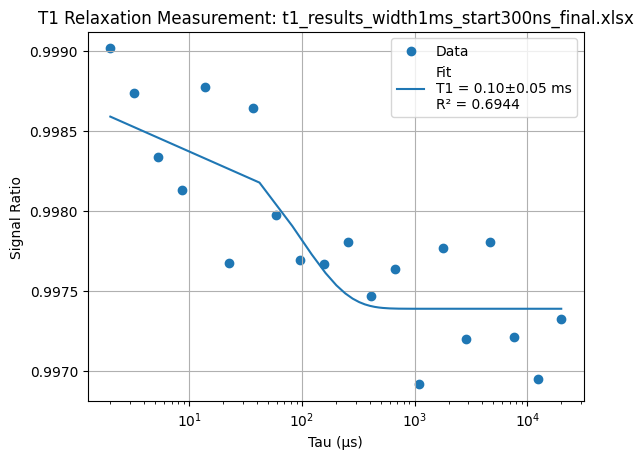

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- LOAD DATA ---
# input_file_name = input("input the file name: ")
input_file_name = "t1_results_width1ms_start300ns_final"
file_name = f"{input_file_name}.xlsx"  # change if needed
df = pd.read_excel(file_name)

tau_us = df["Tau (us)"].values
ratio = df["Ratio"].values

# Convert to seconds
t = tau_us * 1e-6

# --- MODEL ---
def exp_decay(t, I0, A, T1):
    return I0 + A * np.exp(-t / T1)


# --- INITIAL GUESS ---
p0 = [min(ratio), max(ratio)-min(ratio), 1e-3]


# --- FIT ---
params, covariance = curve_fit(exp_decay, t, ratio, p0=p0)

I0, A, T1 = params

# Standard deviations (uncertainty)
perr = np.sqrt(np.diag(covariance))
I0_err, A_err, T1_err = perr


# --- R^2 CALCULATION ---
y_fit_data = exp_decay(t, *params)

ss_res = np.sum((ratio - y_fit_data) ** 2)
ss_tot = np.sum((ratio - np.mean(ratio)) ** 2)

R2 = 1 - (ss_res / ss_tot)


# --- PRINT RESULTS ---
print(f"T1 = {T1:.4e} ± {T1_err:.1e} s")
print(f"T1 = {T1*1e3:.2f} ± {T1_err*1e3:.2f} ms")
print(f"R^2 = {R2:.5f}")


# --- GENERATE SMOOTH FIT CURVE ---
t_fit = np.linspace(min(t), max(t), 500)
y_fit = exp_decay(t_fit, *params)


# --- PLOT ---
plt.figure()

# Data
plt.scatter(tau_us, ratio, label="Data")

# Fit
plt.plot(t_fit*1e6, y_fit,
         label=f"Fit\nT1 = {T1*1e3:.2f}±{T1_err*1e3:.2f} ms\nR² = {R2:.4f}")

plt.xscale("log")
plt.xlabel("Tau (µs)")
plt.ylabel("Signal Ratio")
plt.title(f"T1 Relaxation Measurement: {file_name}")

plt.grid(True)
plt.legend()

plt.show()

In [3]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


## 2 (linear scale)

C:\Users\trina\AppData\Local\Temp\ipykernel_41948\1991513930.py:21: RuntimeWarning: overflow encountered in exp
  return I0 + A * np.exp(-t / T1)


T1 = 5.3605e-05 ± 1.1e-05 s
T1 = 0.05 ± 0.01 ms
R^2 = 0.86411
0.9980544900116346 + 0.0011327742682597957exp(-t)/0.05


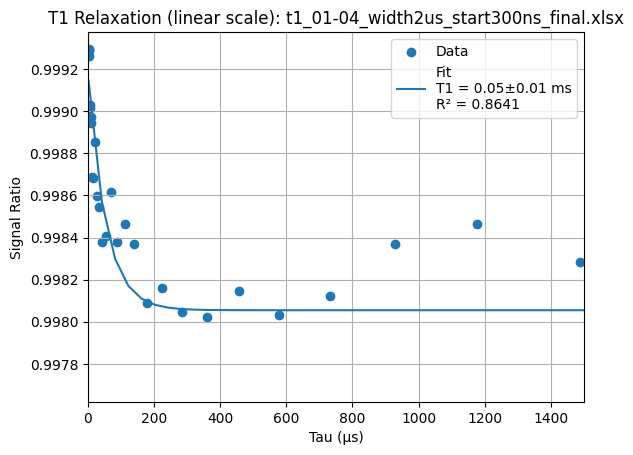

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- LOAD DATA ---
# input_file_name = input("input the file name: ")
input_file_name = "t1_01-04_width2us_start300ns_final"
file_name = f"{input_file_name}.xlsx"  # change if needed
df = pd.read_excel(file_name)

tau_us = df["Tau (us)"].values
# tau_us = np.geomspace(2,20000,40)
ratio = df["Ratio"].values

# Convert to seconds
t = tau_us * 1e-6

# --- MODEL ---
def exp_decay(t, I0, A, T1):
    return I0 + A * np.exp(-t / T1)


# --- INITIAL GUESS ---
p0 = [min(ratio), max(ratio)-min(ratio), 1e-3]


# --- FIT ---
params, covariance = curve_fit(exp_decay, t, ratio, p0=p0)

I0, A, T1 = params

# Standard deviations (uncertainty)
perr = np.sqrt(np.diag(covariance))
I0_err, A_err, T1_err = perr


# --- R^2 CALCULATION ---
y_fit_data = exp_decay(t, *params)

ss_res = np.sum((ratio - y_fit_data) ** 2)
ss_tot = np.sum((ratio - np.mean(ratio)) ** 2)

R2 = 1 - (ss_res / ss_tot)


# --- PRINT RESULTS ---
print(f"T1 = {T1:.4e} ± {T1_err:.1e} s")
print(f"T1 = {T1*1e3:.2f} ± {T1_err*1e3:.2f} ms")
print(f"R^2 = {R2:.5f}")
print(f"{I0} + {A}exp(-t)/{T1*1e3:.2f}")


# --- GENERATE SMOOTH FIT CURVE ---
t_fit = np.linspace(min(t), max(t), 500)
y_fit = exp_decay(t_fit, *params)


# --- PLOT ---
plt.figure()

# Data
plt.scatter(tau_us, ratio, label="Data")

# Fit
plt.plot(t_fit*1e6, y_fit,
         label=f"Fit\nT1 = {T1*1e3:.2f}±{T1_err*1e3:.2f} ms\nR² = {R2:.4f}")

# plt.xscale("log")
plt.xlabel("Tau (µs)")
plt.ylabel("Signal Ratio")
plt.title(f"T1 Relaxation (linear scale): {file_name}")

# ZOOM IN
plt.xlim(0, 1500)

plt.grid(True)
plt.legend()

plt.show()

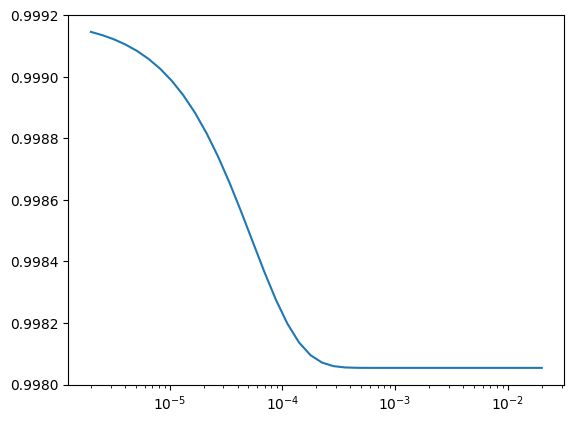

In [ ]:
# with the known parameters from the results above
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

x = np.geomspace(2,20000,40)*1e-6
y = 0.9980544900116346 + 0.0011327742682597957*np.exp(-x/5.3604888259915576e-5)

plt.xscale("log")
plt.plot(x,y)

## 3 (with error bars)


Tau (us) | Ratio | STD (Ratio Error)
    2.00 | 9.9929e-01 | 2.18e-04
    2.53 | 9.9926e-01 | 2.18e-04
    3.21 | 9.9929e-01 | 2.19e-04
    4.06 | 9.9930e-01 | 2.19e-04
    5.14 | 9.9901e-01 | 2.19e-04
    6.51 | 9.9903e-01 | 2.19e-04
    8.25 | 9.9894e-01 | 2.19e-04
   10.45 | 9.9897e-01 | 2.20e-04
   13.23 | 9.9869e-01 | 2.19e-04
   16.75 | 9.9868e-01 | 2.20e-04
   21.22 | 9.9885e-01 | 2.19e-04
   26.87 | 9.9860e-01 | 2.19e-04
   34.03 | 9.9854e-01 | 2.20e-04
   43.09 | 9.9838e-01 | 2.19e-04
   54.57 | 9.9841e-01 | 2.20e-04
   69.10 | 9.9862e-01 | 2.19e-04
   87.51 | 9.9838e-01 | 2.19e-04
  110.82 | 9.9846e-01 | 2.19e-04
  140.34 | 9.9837e-01 | 2.19e-04
  177.72 | 9.9809e-01 | 2.19e-04
  225.07 | 9.9816e-01 | 2.19e-04
  285.02 | 9.9805e-01 | 2.19e-04
  360.94 | 9.9802e-01 | 2.21e-04
  457.09 | 9.9815e-01 | 2.21e-04
  578.85 | 9.9803e-01 | 2.19e-04
  733.05 | 9.9812e-01 | 2.20e-04
  928.32 | 9.9837e-01 | 2.21e-04
 1175.60 | 9.9847e-01 | 2.22e-04
 1488.76 | 9.9828e-01 | 2.22e-04
 1885

C:\Users\trina\AppData\Local\Temp\ipykernel_41948\2430221779.py:19: RuntimeWarning: overflow encountered in exp
  return I0 + A * np.exp(-t / T1)


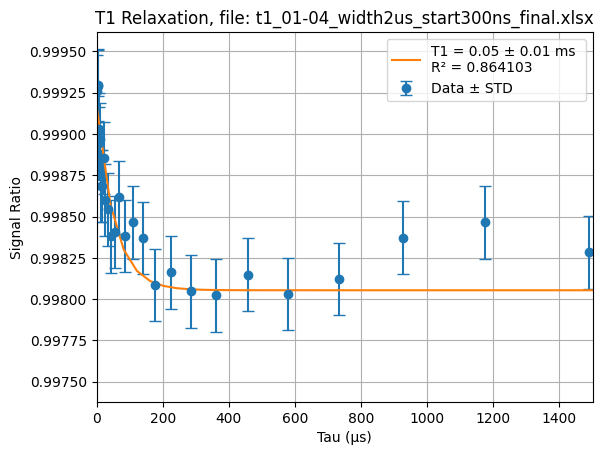

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- LOAD DATA ---
file_name = "t1_01-04_width2us_start300ns_final.xlsx"
df = pd.read_excel(file_name)  # change file name

tau_us = df["Tau (us)"].values
ratio = df["Ratio"].values
ratio_err = df["Ratio Error"].values

t = tau_us * 1e-6


# --- MODEL ---
def exp_decay(t, I0, A, T1):
    return I0 + A * np.exp(-t / T1)


# --- WEIGHTED FIT (IMPORTANT) ---
p0 = [min(ratio), max(ratio)-min(ratio), 1e-3]

params, cov = curve_fit(
    exp_decay,
    t,
    ratio,
    p0=p0,
    sigma=ratio_err,
    absolute_sigma=True
)

I0, A, T1 = params
T1_err = np.sqrt(np.diag(cov))[2]

# --- R^2 CALCULATION ---
y_fit_data = exp_decay(t, *params)

ss_res = np.sum((ratio - y_fit_data) ** 2)
ss_tot = np.sum((ratio - np.mean(ratio)) ** 2)

R2 = 1 - (ss_res / ss_tot)

# --- PRINT EACH DATA POINT WITH STD ---
print("\nTau (us) | Ratio | STD (Ratio Error)")
for tau_val, r, err in zip(tau_us, ratio, ratio_err):
    print(f"{tau_val:8.2f} | {r:8.4e} | {err:.2e}")


# --- GENERATE FIT ---
t_fit = np.linspace(min(t), max(t), 500)
y_fit = exp_decay(t_fit, *params)
print(f"Ratio = {I0:.4f} + {A:.4f}exp(-t)/{T1}")

# --- PLOT ---
plt.figure()

# Error bars (this IS the STD)
plt.errorbar(
    tau_us,
    ratio,
    yerr=ratio_err,
    fmt='o',
    capsize=4,
    label="Data ± STD"
)

# Fit curve
plt.plot(
    t_fit * 1e6,
    y_fit,
    label=f"T1 = {T1*1e3:.2f} ± {T1_err*1e3:.2f} ms \nR² = {R2:.6f}"
)

# --- OPTIONAL: annotate each point ---
# for x, y, err in zip(tau_us, ratio, ratio_err):
#     plt.text(x, y, f"{err:.1e}", fontsize=7)

# plt.xscale("log")
plt.xlabel("Tau (µs)")
plt.ylabel("Signal Ratio")
plt.title(f"T1 Relaxation, file: {file_name}")

# ZOOM IN
plt.xlim(0, 1500)

plt.grid(True)
plt.legend()

plt.show()